![alt text](images/Graphically%20Supported%20Hypotheses.png)

# Common Cause

The statistical dependency between two variables can be due to a common cause. For instance, it had been reported that among students, smokers had higher university degrees than non-smokers. This association was due to student age as a common cause. With time, students are more likely to have started smoking and to have advanced further in their studies.

Plots can help to identify such situations. One can stratify by age and show that this positive association vanishes. This rules out a causal association because a causal association is expected to hold for all ages (or at least at some age).

## Experiment

1 - We toss a fair coin twice and record $z$
 the number of heads obtained. 
 is thus equal to 0,1, or 2.

2- We draw a value $x$
 randomly according to a Gaussian distribution with mean equals to $z$
 and standard deviation 1. Hence, 
 will be a random real number that tend to have higher values with higher values of $z$
. 

$x \sim \mathcal{N}(z, 1)$

3- We draw a value $y$
 randomly according to a Gaussian distribution with mean equals to $z * 2$
 and standard deviation 1. Hence $y$
 will be a random real number that tend to have higher values with higher values of $z$
.

$y \sim \mathcal{N}(z*2, 1)$


In [1]:
#############
# COMMON CAUSE
# X <- Z -> Y
#############

from scipy.stats import norm, binom
from plotnine import *
import pandas as pd
import numpy as np

n = 1000 # number of draws

z = binom.rvs(n = 2, p = 0.5, size = n)

x = norm.rvs(loc = z, scale = 1, size = n)

y = norm.rvs(loc = z, scale = 1, size = n)

In [2]:
# Make the DataFrame

df_common_cause = pd.DataFrame({
    'x':x,
    'y':y,
    'z': pd.Categorical(['z=' + str(val) for val in z])
})

In [3]:
df_common_cause['z'].value_counts()

z
z=1    530
z=0    250
z=2    220
Name: count, dtype: int64

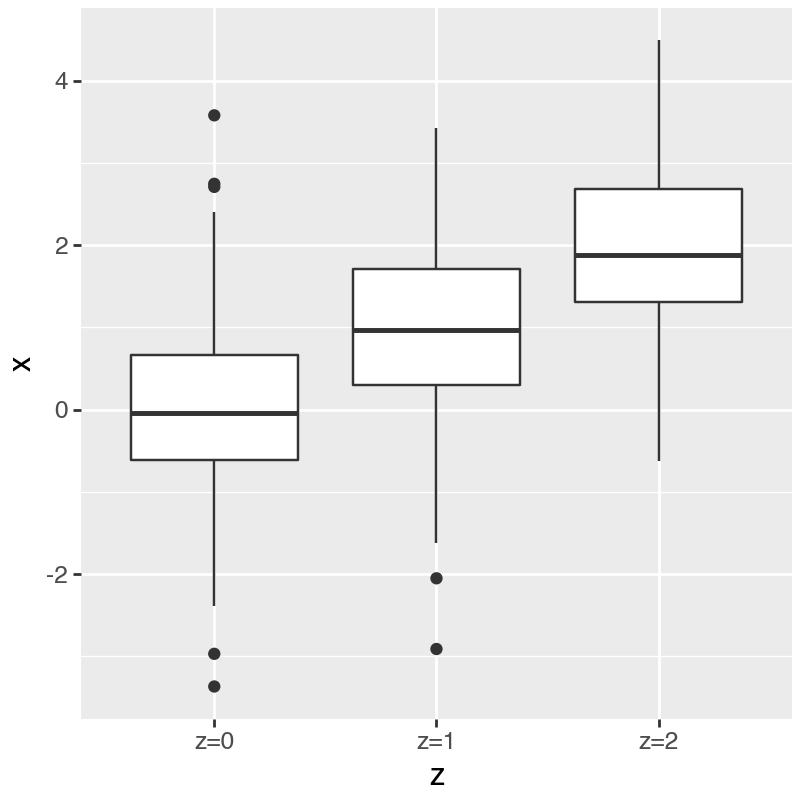

In [4]:
(
    ggplot(df_common_cause, aes(x = 'z', y = 'x')) +
    geom_boxplot() + theme(figure_size= (4,4))
)

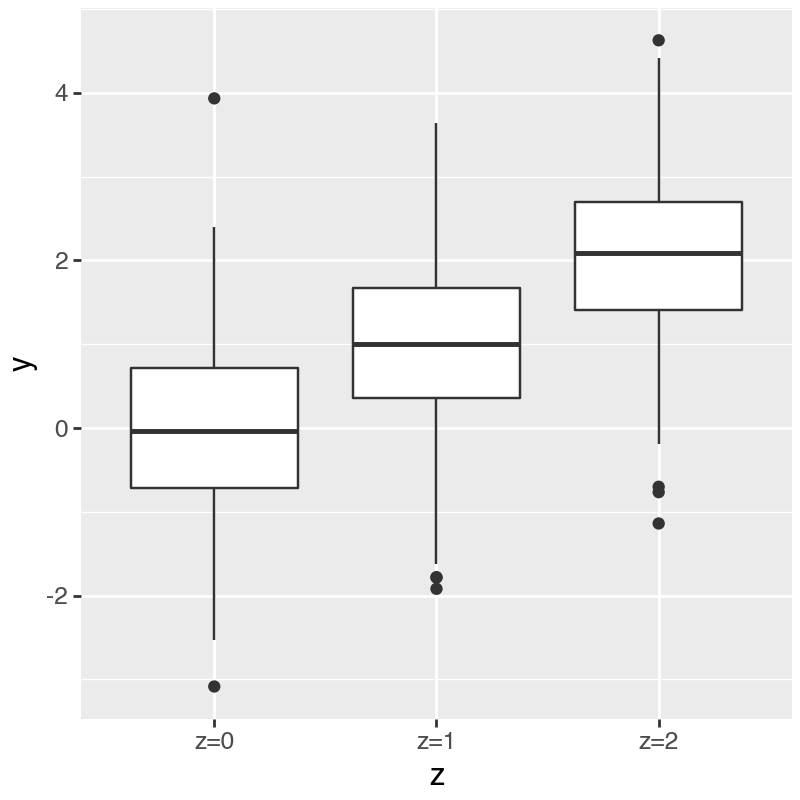

In [5]:
(
    ggplot(df_common_cause, aes(x = 'z', y= 'y')) +
    geom_boxplot() + theme( figure_size= (4,4))
)

As a consequence, x and y are correlate with each other

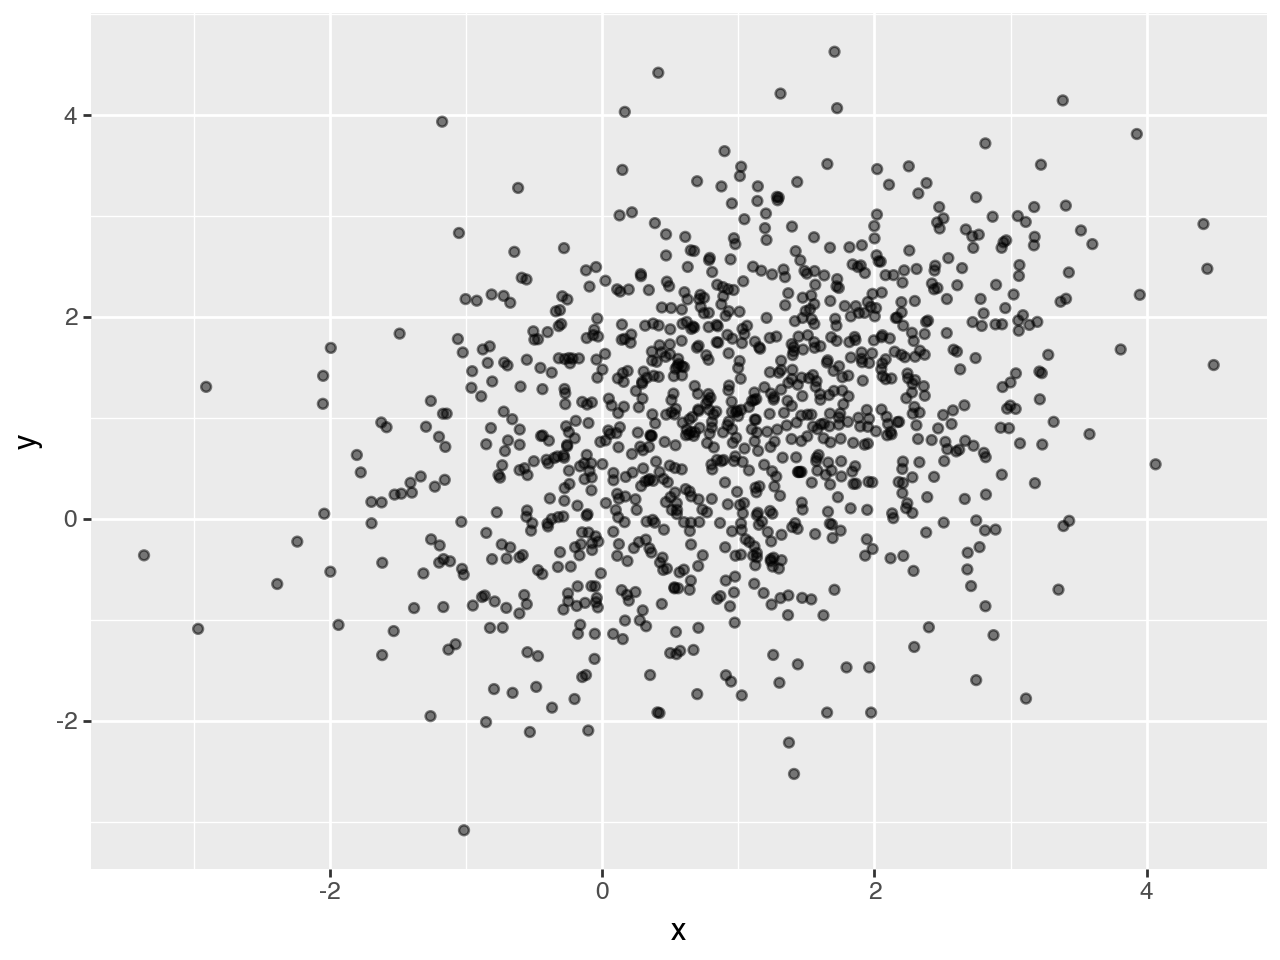

In [6]:
(
    ggplot(df_common_cause, aes(x = 'x', y = 'y')) + 
    geom_point( alpha = 0.5) 
)

In [7]:
df_common_cause['x'].corr(df_common_cause['y'])

np.float64(0.3104394363379173)

This correlation between $x$ and $y$ is due to the common cause $z$. To show the evidince for this issue, one can plot stratified by the values of $z$. In each group, there is no association between $x$ and $y$.

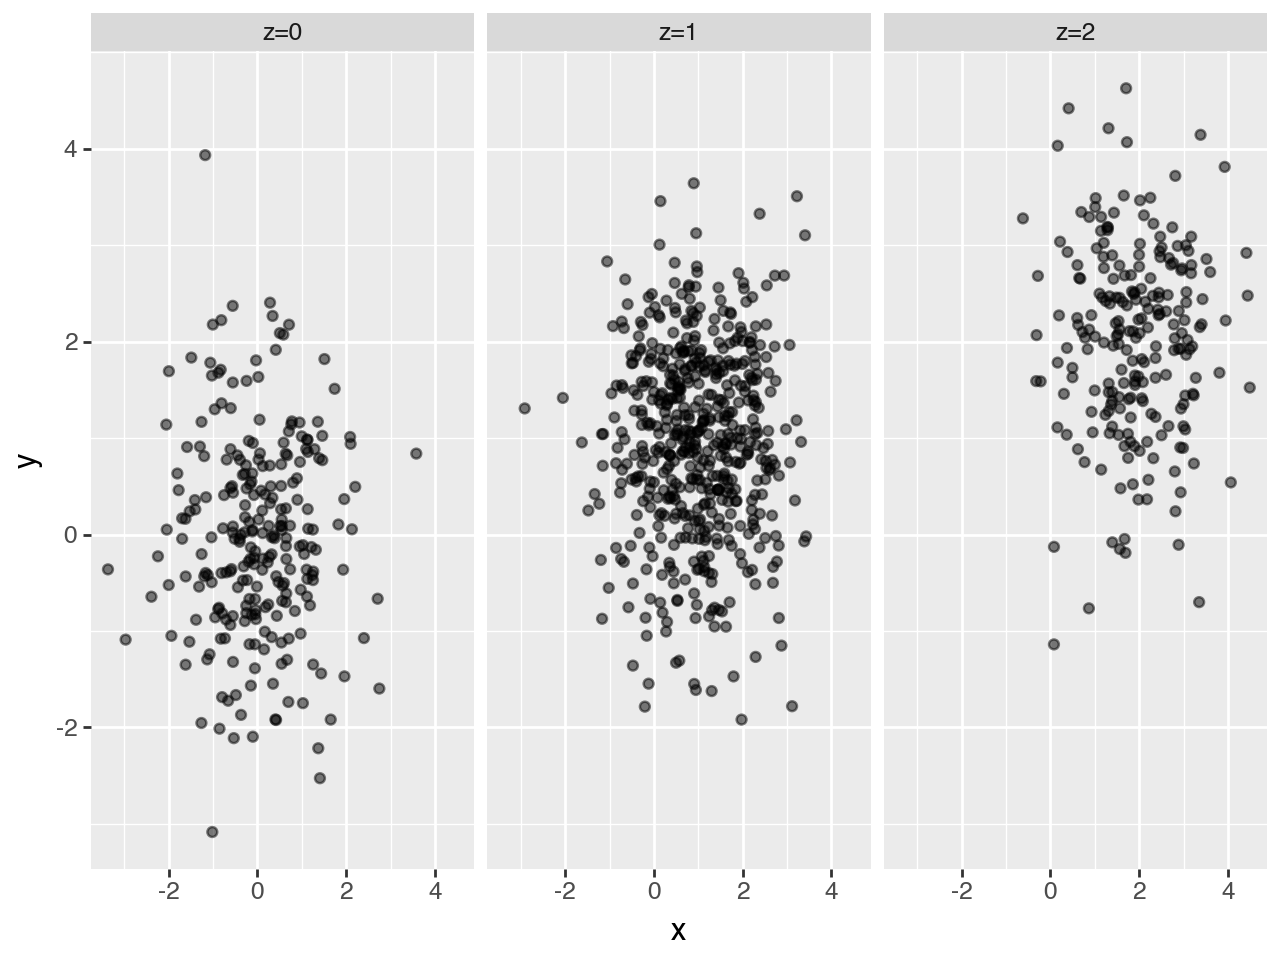

In [8]:
(
    ggplot(df_common_cause, aes(x = 'x', y = 'y')) + 
    geom_point( alpha = 0.5) + 
    facet_wrap('~z') 
)

In [9]:
df_common_cause.groupby('z').apply(lambda df: df['x'].corr(df['y'])).to_frame('correlation')

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_33166/163950901.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_33166/163950901.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,correlation
z,
z=0,-0.007730
z=1,0.008190
z=2,0.002439


Thus Correlation never proves causation. However, conditioning can rule out causation !!!!

# Indirect Association

Consider the following process:

1- We toss a coin once. We record $x = 1$
 if it is a head, and $x = 0$
 if it is a tail.

2- If $x = 0$
, we toss the coin once. If $x = 1$
, we toss the coins twice. We record $z$
, the number of heads of this second step.

3- We draw a value $y$
 randomly according to a Gaussian distribution with mean equal to $z$
 and standard deviation 0.5. Hence, $y$
 will be a random real number that tend to have higher values with higher values of $z$
.

In [13]:
x_indirect = binom.rvs(n=1, p = 0.5, size = n)

z_indirect = binom.rvs(n=x_indirect + 1, p=0.5, size=n)

y_indirect = norm.rvs(loc = z_indirect, scale = 0.5, size = n)

df_indirect = pd.DataFrame({
    'x' : pd.Categorical('x=' + str(val) for val in x_indirect),
    'y' : y_indirect,
    'z' : pd.Categorical('z=' + str(val) for val in z_indirect)  
})

We see that y associates with x:

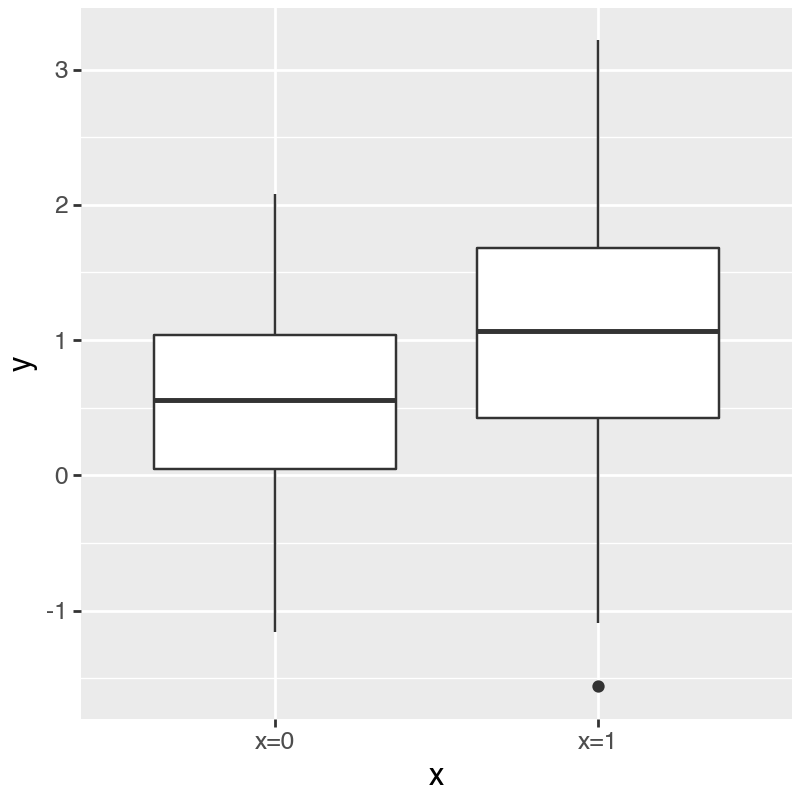

In [14]:
(
    ggplot(df_indirect, aes(x = 'x', y = 'y'))+
    geom_boxplot() + 
    theme(figure_size=(4,4))
)

However this assocations vanishes when we condition on $z$

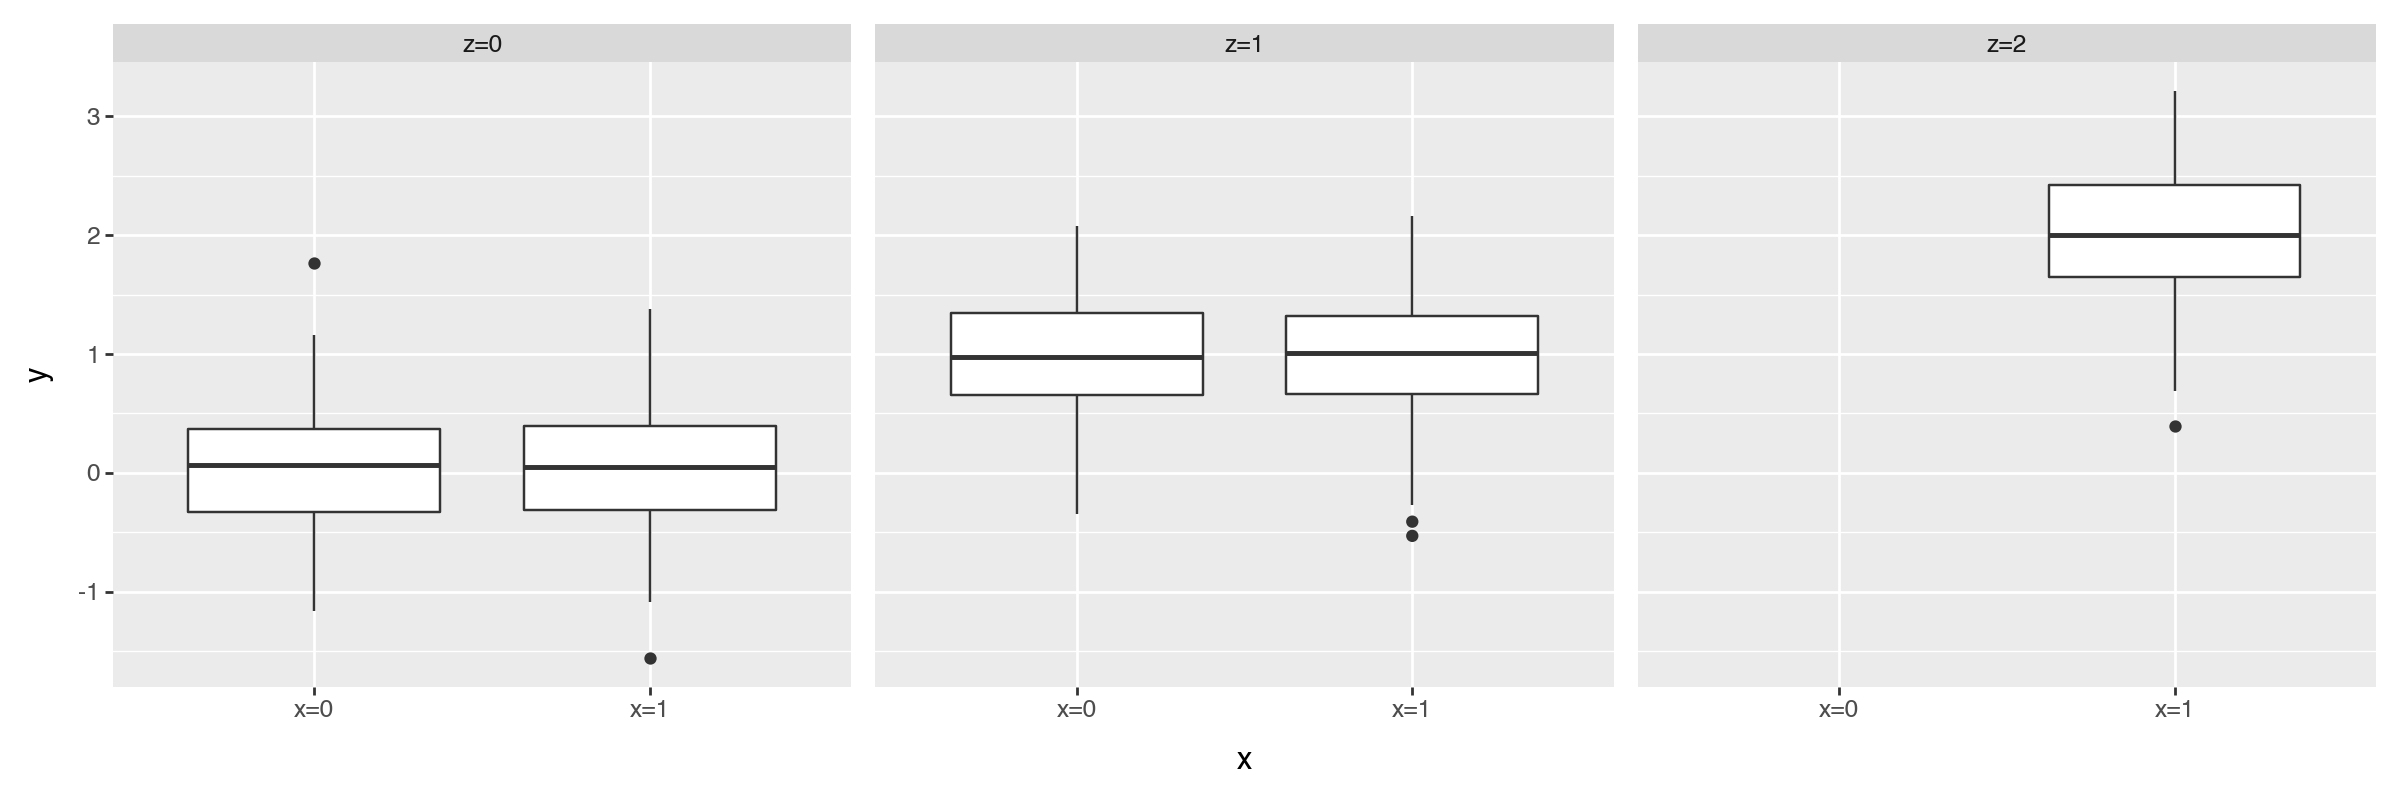

In [15]:
(
    ggplot(df_indirect, aes(x = 'x', y = 'y')) +
    geom_boxplot()+
    facet_wrap('~z')+
    theme(figure_size=(12,4))
)

Conditioning on the third variable has helped ruling out a direct causal relation between 
$x$ and $y$ 
. Note, however, that in this simulation there is an indirect causal relation between 
$x$ and $y$ 
. From an observational data point of view, the situation is very similar to the common cause situation. Interpretations from the application field are needed to suggest whether such data supports an indirect association or a common cause.

## Example

In [23]:
df_admissions = pd.read_csv('Datasets/UCB Admissions.csv')

df_admissions['is_admitted'] = np.where(df_admissions['Admit'] == 'Admitted', 1, 0)

df_admissions

,Unnamed: 0,Admit,Gender,Dept,Freq,is_admitted
0,1,Admitted,Male,A,512,1
1,2,Rejected,Male,A,313,0
2,3,Admitted,Female,A,89,1
3,4,Rejected,Female,A,19,0
4,5,Admitted,Male,B,353,1
5,6,Rejected,Male,B,207,0
6,7,Admitted,Female,B,17,1
7,8,Rejected,Female,B,8,0
8,9,Admitted,Male,C,120,1
9,10,Rejected,Male,C,205,0


In [24]:

(
    df_admissions.groupby('Gender')
    .apply(lambda g : (g['is_admitted'] * g['Freq']).sum() / g['Freq'].sum() )
    .to_frame('Admission Rate')
)

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_33166/3233510546.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,Admission Rate
Gender,
Female,0.303542
Male,0.445188


Closer inspection shows a paradoxical result. Here are the percent admissions by major:

In [30]:
stats = (
    df_admissions.groupby(['Dept', 'Gender'])
    .apply(lambda g : (g['is_admitted'] * g['Freq']).sum() / g['Freq'].sum())
    .unstack(level = 'Gender')
    .assign(women_minus_men = lambda x : x['Female'] - x['Male'])
)

stats

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_33166/758902063.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


Gender,Female,Male,women_minus_men
Dept,,,
A,0.824074,0.620606,0.203468
B,0.680000,0.630357,0.049643
C,0.340641,0.369231,-0.028590
D,0.349333,0.330935,0.018398
E,0.239186,0.277487,-0.038301
F,0.070381,0.058981,0.011400


Four out of the six majors favor women. More importantly, all the differences are much smaller than the 14.2 difference that we see when examining the totals.

The paradox is that analyzing the totals suggests a dependence between admission and gender, but when the data is grouped by major, this dependence seems to disappear. What’s going on? This actually can happen if an uncounted confounder is driving most of the variability.

We define three variables $X, Y, Z$

* $X$ is $1$ for men and $0$ for women 
* $Y$ is $1$ for those admitted and $0$ otherwise
* $Z$ quantifies the selectivity of the major

A gender bias claim would be based on the fact that $Pr(Y=1 | X=x)$ is higher for $x=1$ than $x=0$.

HOWEVER, $Z$ is an important cofounder to consider. Clearly $Z$ is associated with $Y$, as the more selective a major, the lower $Pr(Y=1 | Z = z)$.

But is major selectivity $Z$ associated with gender $X$ ?  




One way to see this is to plot the total percent admitted to a major versus the percent of women that made up the applicants:

In [40]:
df_admissions['is_female'] = np.where(df_admissions['Gender'] == 'Female', 1,0)

selectivity_versus_percentage_women = (
    df_admissions.groupby('Dept')
    .agg(
        selectivity_rate = ('Freq',
            lambda x : (df_admissions.loc[x.index, 'is_admitted'] * x).sum() / x.sum()
        ),
        percent_women_applications = ('Freq',
            lambda x : (df_admissions.loc[x.index, 'is_female'] * x).sum() / x.sum() * 100                             
        )
    ).reset_index()
)

selectivity_versus_percentage_women

,Dept,selectivity_rate,percent_women_applications
0,A,0.644159,11.575563
1,B,0.632479,4.273504
2,C,0.350763,64.596950
3,D,0.339646,47.348485
4,E,0.251712,67.294521
5,F,0.064426,47.759104


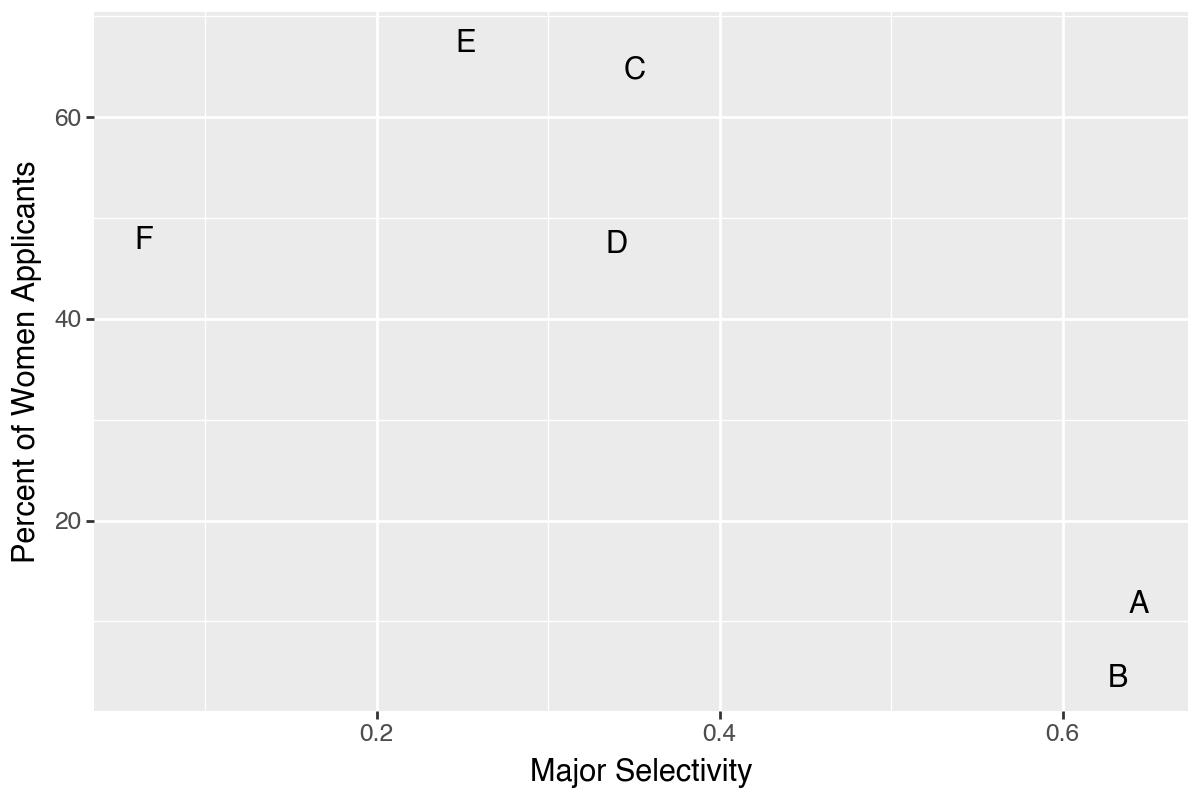

In [45]:
(
    ggplot(selectivity_versus_percentage_women, aes('selectivity_rate', 'percent_women_applications', label = 'Dept')) + 
    geom_text() +
    labs(x = 'Major Selectivity', y = 'Percent of Women Applicants') +
    theme(figure_size= (6,4))
)

There seems to be association. The plot suggests that women were much more likely to apply to the two “hard” majors: gender and major’s selectivity are confounded. Compare, for example, major B and major E. Major E is much harder to enter than major B and over 60% of applicants to major E were women, while less than 30% of the applicants of major B were women.



The following plot shows the number of applicants that were admitted and those that were not by gender and major:

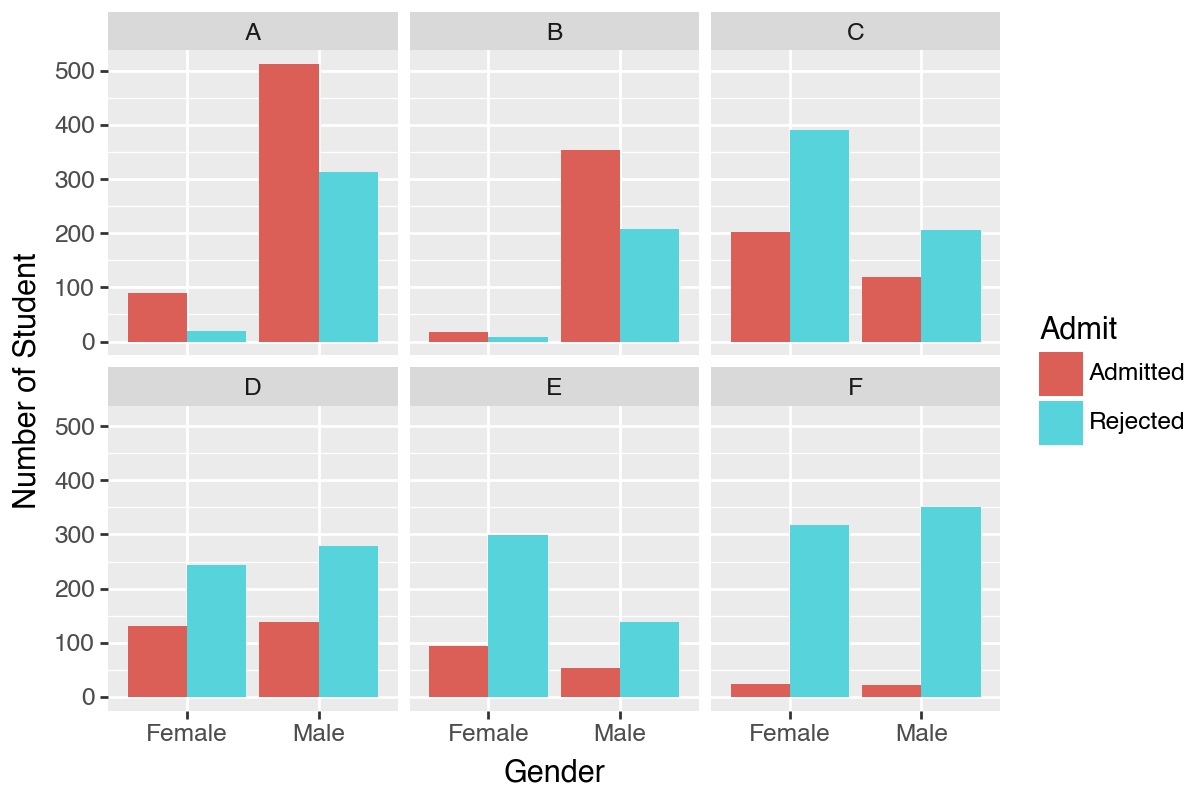

In [50]:
(
    ggplot(df_admissions, aes('Gender', 'Freq', fill = 'Admit')) +
    geom_bar(stat = 'identity', position = 'dodge') + 
    facet_wrap('~Dept') + 
    labs(x = 'Gender', y = 'Number of Student') + 
    theme(figure_size= (6,4))
)

The visualization breaks down the acceptances by major. 

This breakdown allows us to see that the majority of accepted men came from two majors: A and B. It also lets us see that few women applied to these majors.

Changing the position to $'fill'$ in geom_bar() returns the following plot:

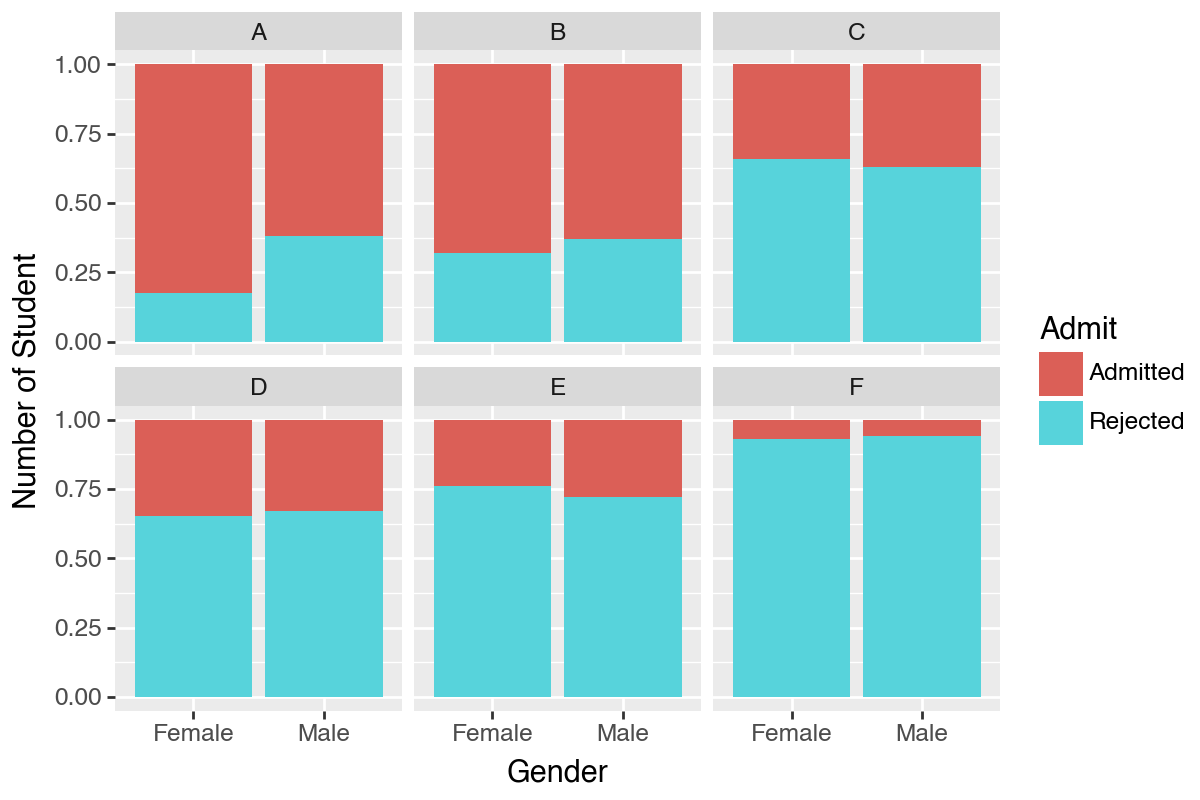

In [52]:
(
    ggplot(df_admissions, aes('Gender', 'Freq', fill = 'Admit')) +
    geom_bar(stat = 'identity', position = 'fill') + 
    facet_wrap('~Dept') + 
    labs(x = 'Gender', y = 'Number of Student') + 
    theme(figure_size= (6,4))
)

Setting "fill" as the position argument makes each set of stacked bars to have the same height. This makes it easier to compare proportions across groups. However, note that it can be hard to compare some groups with increasing number of stacked bars.

Altogether, this data suggests the following causal interpretation:

Gender $\rarr$ Major $\rarr$ Admission

In this interpretation of this data, women are proportionally less admitted because they choose more selective majors. Hence the association is correct, causal, in the right orientation, but it is indirect.

# Common Consequence

One fun imaginary example is given by Judea Pearl in “The Book of Why” 3 about talent and beauty among Hollywood stars.

We assume that:

* Talent for acting is a quantitative value $x$ that is randomly distributed among the human population.

* Beauty is a quantitative value $y$
 randomly distributed among the human population and independently of talent for acting.

* Hollywood stars must have talent for acting and beauty or be very beautiful or very good actors.

We can use computer to simulate such a situation as:

* draw $x$ with Gaussian of mean $0$ and standard deviation $1$

* draw $y$ with Gaussian of mean $0$ and standard deviation $1$ independent of $x$ 

* let $z = 1$ if $x + y > 1$

In [53]:
#####################
# COMMON CONSEQUENCE
# X -> Z <- Y
#####################

x_conseq = norm.rvs(loc = 0, scale = 1, size = n)
y_conseq = norm.rvs(loc = 0, scale = 1, size = n)
z_conseq = (x_conseq + y_conseq) > 1

df_conseq = pd.DataFrame({
    'x': x_conseq,
    'y': y_conseq,
    'z': z_conseq
})

In our simulated population, beauty and talent for acting do not correlate:

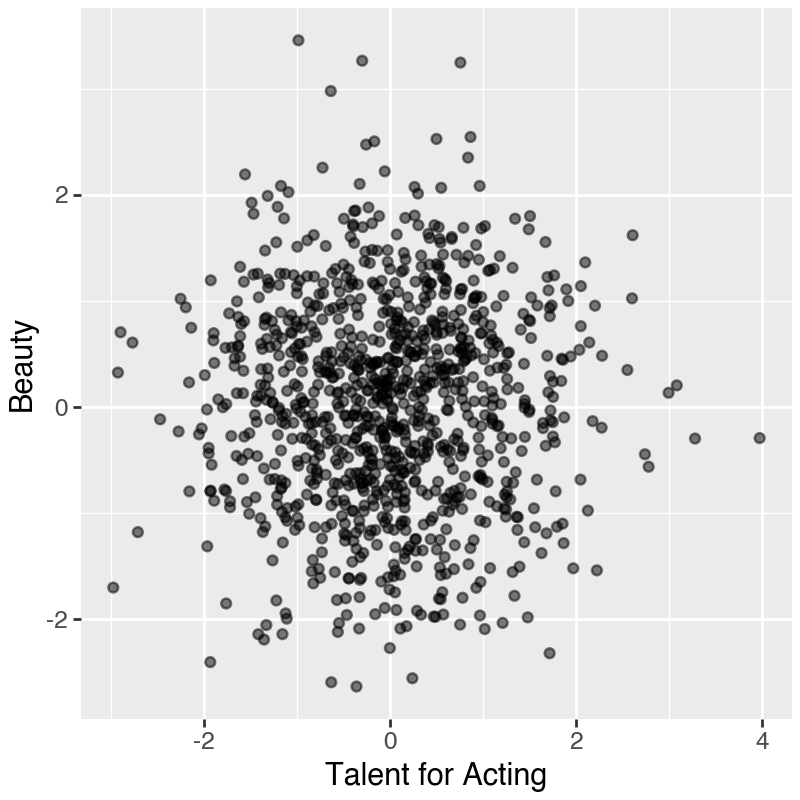

In [56]:
(
    ggplot(df_conseq, aes(x = 'x', y = 'y')) + 
    geom_point(alpha = 0.5) + 
    labs(x = 'Talent for Acting', y = 'Beauty') + 
    theme(figure_size= (4,4))
)

In [57]:
df_conseq['x'].corr(df_conseq['y'])

np.float64(0.011183431570093948)

The fun paradox comes when we restrict our analysis to the Hollywood stars:

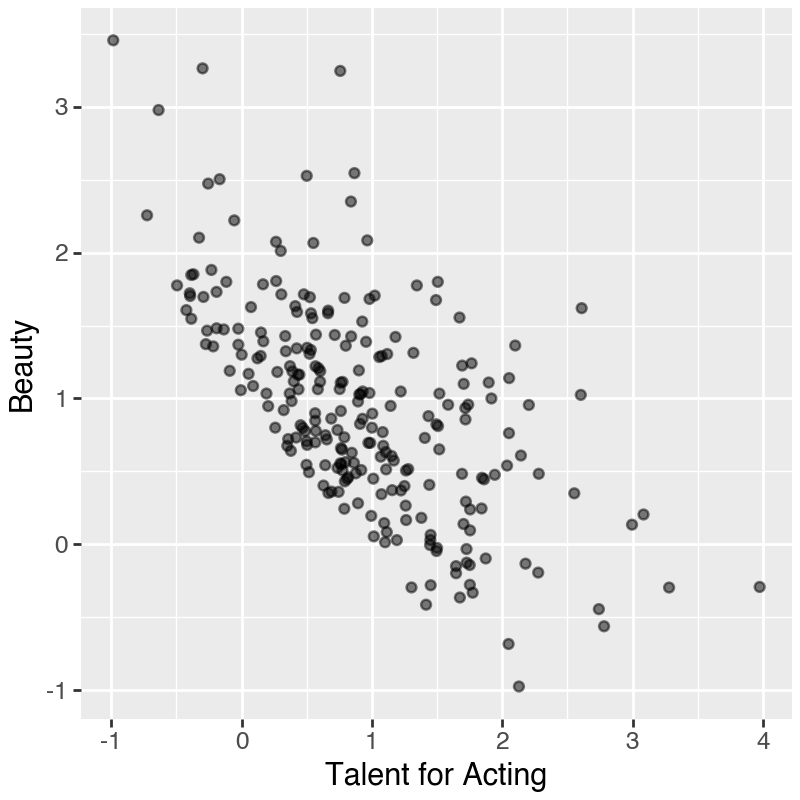

In [64]:
df_conseq_filter = df_conseq[df_conseq.z == True]

(
    ggplot(df_conseq_filter, aes(x='x', y='y')) +
    geom_point(alpha = 0.5) +
    labs(x = 'Talent for Acting', y = 'Beauty') +
    theme(figure_size= (4,4))
)

In [65]:
df_conseq_filter['x'].corr(df_conseq_filter['y'])

np.float64(-0.6262518636985284)

Hence, beautiful Hollywood stars tend to act worse than than less beautiful stars.

This paradox is known as Berkson’s paradox 
https://en.wikipedia.org/wiki/Berkson%27s_paradox


Altogether, the association arises once we condition on the third variable. This has two implications. First, conditioning should not be done systematically. Second, the data may already be conditioned and we are not aware of it! The data may have undergone some filtering during data analysis, or, less obviously, during data collection. Those possibilities should be considered when reporting associations between variables.



# Simpson's Paradox

In 1951, Simpson demonstrated that a statistical relationship observed within a group of individuals could be reversed within all subgroups that make up that population. This phenomenon, where a variable X seems to relate to a second variable Y in a certain way, but flips direction when the stratifying for another variable Z, has since been referred to as Simpson’s paradox.



![alt text](images/Graphically%20Supported%20Hypotheses%20(1).png)

To illustrate the Simpson’s paradox we simulate a dataset with three variables: $X, Y, Z$

When visualizing the relationship between the variables $X$ and $Y$, we observe a negative correlation between $X$ and $Y$:


<img src="images/Graphically%20Supported%20Hypotheses%20(2).png" width="700">

However, when grouping by the variable Z, we observe a positive correlation which is the opposite direction as before:

<img src="images/Graphically%20Supported%20Hypotheses%20(3).png" width="700">

-------

# Data Presentation as Story Telling

Data presentation plays an essential role in every field from academic studies to professional practices. However, it is often underestimated. Sometimes people work really hard on what they aim to present but fail to present it properly. The actual output of the analysis performed is almost singularly responsible for giving the message we want to give to the audience. For this, we have to first really understand who our audience is considering its background and interests.

After spending some time reflecting on the audience, we want to be able to present the data and its analysis clearly and efficiently. We want to create a good presentation that, like a good story, is easy to understand, has a clear message and is exciting.



Before discussing strategies for turning visualizations into stories, we have to understand what a story actually is. A story is a set of observations, facts, or events, that are presented in a specific order such that they create an emotional reaction in the audience. The emotional reaction is created through the build-up of tension at the beginning of the story followed by some type of resolution towards the end of the story. We refer to the flow from tension to resolution also as the story arc, and every good story has a clear, identifiable arc.

Commonly, a story teller first introduces the topic, then presents the challenge followed by a series of actions. Finally, the resolution is presented.

-----

## Presentation Structure

### Introduction

A presentation should have an introduction which clearly states the motivation to the topic, gives an overview on the background needed to understand the data and finally states the goals of the presentation. The open questions should be formulated here. What is not yet known or unclear in the field that your analysis addresses?

------

### Development

The central part of the presentation is all about transforming hypotheses, claims and results into slides.



Two common misconceptions have to be avoided when presenting visualizations in a presentation. 

* First, that the audience can see our figures and immediately infer the points we are trying to make. 
* Second, that the audience can rapidly process complex visualizations and understand the key trends and relationships that are shown. 

We need to do everything we can to help our audience understands the meaning of our visualizations and see the same patterns in the data that we see. This usually means “less is more”.

Sometimes, however, we do want to show more complex figures that contain a large amount of information at once. In those cases, we can make things easier for our audience if we first show a simplified version of the figure before we show the final one in its full complexity.

Usually, we first show descriptive plots to first present the data and let the audience be able to understand the data. Then, we use associative plots to support claims, results and hypotheses.

Ideally, one slide contains exactly one claim supported by one plot. For this, the plot type should be chosen carefully. The title of the slide or figure is a very important element. The title should give the take-home message of the presented visualizations. It is a clear and simple interpretation of the plot. For instance, a title such as “Scatterplot of diamond price versus carat” for Figure 6.1 would not be informative since it is evident from the type of the plot and the axis labels that we look at a scatter plot of price versus carat. More informative is your interpretation of it, which the reader can judge from the plot. Do you want to claim that “Price increases nearly linearly with carat”, or rather that “There remains much price variation among diamonds with the same carat”? Such statements make informative slide titles.

-------

### Closure

The presentation should ideally have a strong closure. We can usually start with a summary of the presentation including a clear conclusion. With the conclusion, the audience should be able to answer the fundamental question: what do we learn from the presented data analysis? The conclusions typically correspond to the open questions formulated in the introduction. Often, an outlook containing possible next steps can be briefly summarized at the end of a presentation.